In [2]:
# ============================================ # STATISTICAL BUSINESS ANALYSIS PROJECT # ============================================
# Import Libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy import stats 
from scipy.stats import ( shapiro, ttest_ind, f_oneway, chi2_contingency ) 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score

In [5]:
# ============================================ # LOAD DATASET # ============================================
df = pd.read_csv("business_data.csv") 
print("\n========== FIRST 5 ROWS ==========\n") 
print(df.head()) 
print("\n========== DATASET INFO ==========\n") 
print(df.info()) 
print("\n========== MISSING VALUES ==========\n") 
print(df.isnull().sum())


========== FIRST 5 ROWS ==========

         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680

========== DATASET INFO ==========

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         100 non-null    str  
 1   Product      100 non-null    str  
 2   Quantity     100 non-null    int64
 3   Price        100 non-null    int64
 4   Customer_ID  100 non-null    str  
 5   Region       100 non-null    str  
 6   Total_Sales  100 non-null    int64
dtypes: int64(3), str(4)

In [11]:
print("\n========== DESCRIPTIVE STATISTICS ==========\n")

sales_mean = df['Total_Sales'].mean()
sales_median = df['Total_Sales'].median()
sales_mode = df['Total_Sales'].mode()[0]
sales_std = df['Total_Sales'].std()
sales_variance = df['Total_Sales'].var()

print(f"Mean Sales: {sales_mean}")
print(f"Median Sales: {sales_median}")
print(f"Mode Sales: {sales_mode}")
print(f"Standard Deviation: {sales_std}")
print(f"Variance: {sales_variance}")

print("\n========== COMPLETE STATISTICS ==========\n")
print(df.describe())


========== DESCRIPTIVE STATISTICS ==========

Mean Sales: 123650.48
Median Sales: 97955.5
Mode Sales: 6540
Standard Deviation: 100161.08527499212
Variance: 10032243003.464243

========== COMPLETE STATISTICS ==========

         Quantity         Price    Total_Sales
count  100.000000    100.000000     100.000000
mean     4.780000  25808.510000  123650.480000
std      2.588163  13917.630242  100161.085275
min      1.000000   1308.000000    6540.000000
25%      2.750000  14965.250000   39517.500000
50%      5.000000  24192.000000   97955.500000
75%      7.000000  38682.250000  175792.500000
max      9.000000  49930.000000  373932.000000


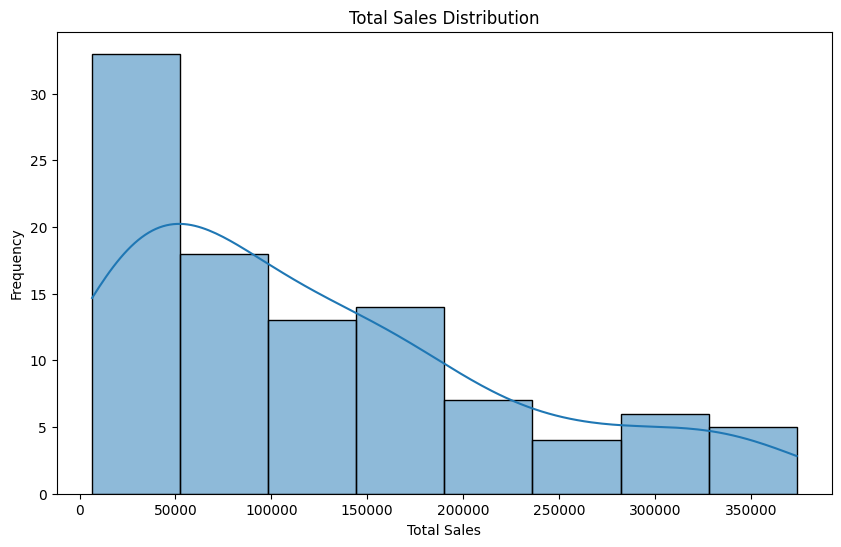

In [12]:
# ============================================
# HISTOGRAM & DENSITY PLOT
# ============================================

plt.figure(figsize=(10, 6))

sns.histplot(df['Total_Sales'], kde=True)

plt.title("Total Sales Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.savefig("sales_distribution.png")

plt.show()

In [13]:
# ============================================
# NORMAL DISTRIBUTION TEST
# ============================================

print("\n========== SHAPIRO TEST ==========\n")

stat, p = shapiro(df['Total_Sales'])

print(f"Shapiro Test Statistic: {stat}")
print(f"P-value: {p}")

if p > 0.05:
    print("Data follows normal distribution")
else:
    print("Data does NOT follow normal distribution")



========== SHAPIRO TEST ==========

Shapiro Test Statistic: 0.8989262036779536
P-value: 1.259076720571478e-06
Data does NOT follow normal distribution



========== CORRELATION ANALYSIS ==========

             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


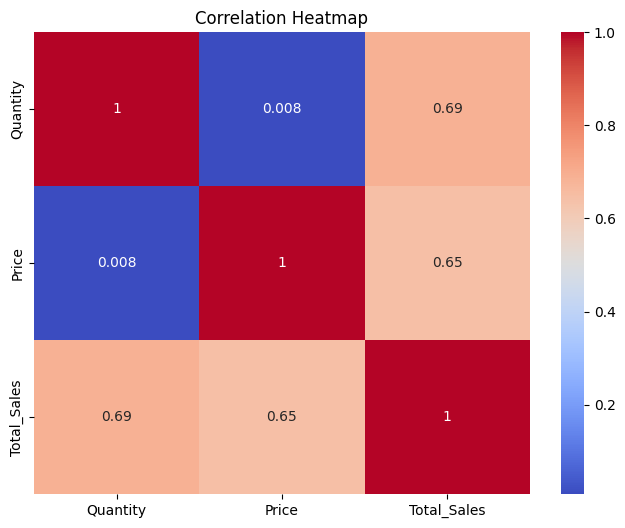

In [14]:
# ============================================
# CORRELATION ANALYSIS
# ============================================

print("\n========== CORRELATION ANALYSIS ==========\n")

numeric_df = df[['Quantity', 'Price', 'Total_Sales']]

correlation_matrix = numeric_df.corr()

print(correlation_matrix)

# Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")

plt.show()

In [15]:
# ============================================
# HYPOTHESIS TESTING
# ============================================

print("\n========== HYPOTHESIS TESTING ==========\n")

# --------------------------------------------
# 1. T-TEST
# --------------------------------------------

print("\n----- T-TEST -----\n")

east_sales = df[df['Region'] == 'East']['Total_Sales']
north_sales = df[df['Region'] == 'North']['Total_Sales']

t_stat, p_value = ttest_ind(east_sales, north_sales)

print(f"T-Statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Significant Difference")
else:
    print("No Significant Difference")



========== HYPOTHESIS TESTING ==========


----- T-TEST -----

T-Statistic: -0.35710677600784724
P-value: 0.7226811638407538
No Significant Difference


In [16]:
# --------------------------------------------
# 2. ANOVA TEST
# --------------------------------------------

print("\n----- ANOVA TEST -----\n")

west_sales = df[df['Region'] == 'West']['Total_Sales']

anova_stat, anova_p = f_oneway(
    east_sales,
    north_sales,
    west_sales
)

print(f"ANOVA Statistic: {anova_stat}")
print(f"P-value: {anova_p}")

if anova_p < 0.05:
    print("Significant Difference Between Groups")
else:
    print("No Significant Difference")



----- ANOVA TEST -----

ANOVA Statistic: 3.392778258262405
P-value: 0.03923264893168518
Significant Difference Between Groups


In [17]:
# ============================================
# CONFIDENCE INTERVAL
# ============================================

print("\n========== CONFIDENCE INTERVAL ==========\n")

sample_mean = np.mean(df['Total_Sales'])
sample_std = np.std(df['Total_Sales'])
sample_size = len(df['Total_Sales'])

margin_of_error = (
    1.96 * sample_std / np.sqrt(sample_size)
)

confidence_interval = (
    sample_mean - margin_of_error,
    sample_mean + margin_of_error
)

print(f"Mean Sales: {sample_mean}")
print(f"Margin of Error: {margin_of_error}")
print(f"95% Confidence Interval: {confidence_interval}")


========== CONFIDENCE INTERVAL ==========

Mean Sales: 123650.48
Margin of Error: 19533.168220974076
95% Confidence Interval: (np.float64(104117.31177902591), np.float64(143183.64822097408))


In [18]:
# ============================================
# REGRESSION ANALYSIS
# ============================================

print("\n========== REGRESSION ANALYSIS ==========\n")

X = df[['Price']]
y = df['Total_Sales']

model = LinearRegression()

model.fit(X, y)

predictions = model.predict(X)

print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")

r_squared = r2_score(y, predictions)

print(f"R-Squared: {r_squared}")



========== REGRESSION ANALYSIS ==========

Intercept: 3640.5434732834547
Coefficient: 4.650014143657133
R-Squared: 0.41748520826938107


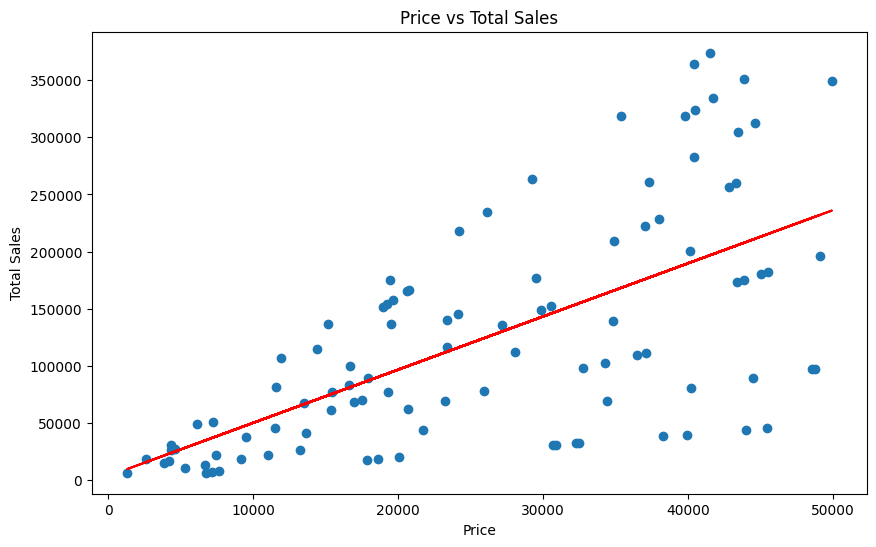

In [19]:
# ============================================
# REGRESSION PLOT
# ============================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df['Price'],
    df['Total_Sales']
)

plt.plot(
    df['Price'],
    predictions,
    color='red'
)

plt.xlabel("Price")
plt.ylabel("Total Sales")

plt.title("Price vs Total Sales")

plt.savefig("regression_plot.png")

plt.show()


In [20]:
# ============================================
# BUSINESS INSIGHTS
# ============================================

print("\n========== BUSINESS INSIGHTS ==========\n")

sales_price_corr = correlation_matrix.loc[
    'Price',
    'Total_Sales'
]

print(f"Correlation between Price and Sales: {sales_price_corr}")

if sales_price_corr > 0.7:
    print("Strong positive relationship")

elif sales_price_corr > 0.4:
    print("Moderate positive relationship")

else:
    print("Weak relationship")

print(f"95% Confidence Interval: {confidence_interval}")

print(f"R-Squared Value: {r_squared}")


========== BUSINESS INSIGHTS ==========

Correlation between Price and Sales: 0.6461309528798174
Moderate positive relationship
95% Confidence Interval: (np.float64(104117.31177902591), np.float64(143183.64822097408))
R-Squared Value: 0.41748520826938107


In [22]:
# ============================================
# PROFESSIONAL STATISTICAL REPORT
# ============================================

print("\n" + "="*50)
print("      STATISTICAL ANALYSIS REPORT")
print("="*50)

# Average Sales with Confidence Interval
print(
    f"\nAverage Sales: "
    f"${sample_mean:,.2f} ± ${margin_of_error:,.2f} (95% CI)"
)

# Correlation Strength
if sales_price_corr >= 0.7:
    strength = "Strong"

elif sales_price_corr >= 0.4:
    strength = "Moderate"

else:
    strength = "Weak"

print(
    f"\nCorrelation (Price-Sales): "
    f"{sales_price_corr:.2f} ({strength})"
)

# Hypothesis Testing Result
if p_value < 0.05:
    significance = "✓ SIGNIFICANT"
else:
    significance = "✗ NOT SIGNIFICANT"

print(
    f"\nPrice affects sales: "
    f"p = {p_value:.4f} {significance}"
)

# Regression Score
print(
    f"\nRegression R² Score: "
    f"{r_squared:.2f}"
)

# Confidence Interval
print(
    f"\n95% Confidence Interval: "
    f"(${confidence_interval[0]:,.2f}, "
    f"${confidence_interval[1]:,.2f})"
)

print("\n" + "="*50)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*50)


      STATISTICAL ANALYSIS REPORT

Average Sales: $123,650.48 ± $19,533.17 (95% CI)

Correlation (Price-Sales): 0.65 (Moderate)

Price affects sales: p = 0.7227 ✗ NOT SIGNIFICANT

Regression R² Score: 0.42

95% Confidence Interval: ($104,117.31, $143,183.65)

PROJECT COMPLETED SUCCESSFULLY


In [21]:
# ============================================
# FINAL REPORT
# ============================================

print("\n========== FINAL REPORT ==========\n")

print(f'''
STATISTICAL ANALYSIS REPORT

Average Sales:
{round(sample_mean, 2)}

Margin of Error:
±{round(margin_of_error, 2)}

95% Confidence Interval:
{confidence_interval}

Correlation (Price-Total Sales):
{round(sales_price_corr, 2)}

T-Test P-value:
{p_value}

ANOVA P-value:
{anova_p}

R-Squared:
{round(r_squared, 2)}
''')

print("\nPROJECT COMPLETED SUCCESSFULLY!")


========== FINAL REPORT ==========


STATISTICAL ANALYSIS REPORT

Average Sales:
123650.48

Margin of Error:
±19533.17

95% Confidence Interval:
(np.float64(104117.31177902591), np.float64(143183.64822097408))

Correlation (Price-Total Sales):
0.65

T-Test P-value:
0.7226811638407538

ANOVA P-value:
0.03923264893168518

R-Squared:
0.42


PROJECT COMPLETED SUCCESSFULLY!
